In [12]:
#import
import os
from keras import backend as K
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt 
from tensorflow.keras.layers import Dropout

Dans la partie ci-dessus on a importe des bibliotheques necessaires pour notre cas ,voire: tensorflow et keras.

In [3]:
os.chdir("./v_data")
img_width, img_height=224,224
train_data_dir='train'
validation_data_dir='test'
nb_train_samples=400
nb_validation_samples=100
epochs=15
batch_size=16
num_filters=8
filtre_size=3
if K.image_data_format() == 'channels_first':
    input_shape=(3,img_width,img_height)
else:
    input_shape=(img_width,img_height,3)
# print("on est sur:",os.getcwd())
# print(img_width , nb_train_samples, nb_train_smaples )

Dans cette partie on a dirige notre programme vers le repertoire contenant notre data "v_data" puis on a defini le train_data_dir et le validation_data_dir (test_set) aussi les elements necessaires pour l'entrainement de notre CNN, comme nombre des iterarions et du batch ,la taille et le nombre filtres qui vont etre appliques.
Puis on a ajoute une condition pour la forme de l'input de l'image.

In [4]:
train_datagen= ImageDataGenerator(rescale=1./255,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
train_generator=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,
                                                  class_mode='categorical')
validation_generator=test_datagen.flow_from_directory(
                        validation_data_dir,
                        target_size=(img_width,img_height),
                        batch_size=batch_size,
                        class_mode='categorical')


train_datagen1=ImageDataGenerator(rescale = 1. / 255)
test_datagen1=ImageDataGenerator(rescale=1./255)
train_generator1=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,class_mode='categorical')
validation_generator1=test_datagen.flow_from_directory(
                        validation_data_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size, class_mode='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


Dans cette partie on a fait le scaling de notre train_set,et on a fait un shear_range de 20% pour deformer un coin de l'image afin de simuler les angles de vue differnete.
On a applique aussi une zoom_range de 20% aussi pour rendre le modele robuste aux differentes tailles des objets.
et horizontal_flip pour donner a notre modele un vue droite et gauche ,c'est utile pour les symetries naturels comme de paysage,des visages mais pas utile au cas ou on a des textes ou des chiffres,dans notre cas de plane/car c'est utile.
On scale aussi le test_set.
puis on a applique un chargement des images de train et de test.
Puis d'autres data-set train test (train_datagen1,validation_generator1), mais cette fois-ci sauf le scaling pas d'autres attributs pour voir comment ca va influencer en performance.

In [5]:
model=keras.Sequential()
model.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

model1=keras.Sequential()
model1.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model1.add(Activation('relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(24))
model1.add(Dense(2))
model1.add(Activation('sigmoid'))
print(model1.summary())

C:\Users\Dell Latitude 7430\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


 Ici on a cree deux modeles de meme architectures CNN pour chacun.Un a entrainer par data_generator1 et l'autre par data_generator 

In [6]:
model.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history=model.fit(train_generator,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator,
                    validation_steps=nb_validation_samples//batch_size)
model1.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history1=model1.fit(train_generator1,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator1,
                    validation_steps=nb_validation_samples//batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 854ms/step - accuracy: 0.6075 - loss: 7.3496 - val_accuracy: 0.7083 - val_loss: 1.2848
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 601ms/step - accuracy: 0.7475 - loss: 0.9505 - val_accuracy: 0.9062 - val_loss: 0.2443
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 585ms/step - accuracy: 0.7950 - loss: 0.5652 - val_accuracy: 0.7604 - val_loss: 0.4441
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 615ms/step - accuracy: 0.8300 - loss: 0.4193 - val_accuracy: 0.7604 - val_loss: 0.5392
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 612ms/step - accuracy: 0.8425 - loss: 0.4092 - val_accuracy: 0.7812 - val_loss: 0.4698
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 600ms/step - accuracy: 0.8900 - loss: 0.3361 - val_accuracy: 0.7292 - val_loss: 0.5697
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 583ms/step - accuracy: 0.9150 - loss: 0.3064 - val_accuracy: 0.7708 - val_loss: 0.5121
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 585ms/step - accuracy: 0.8950 - loss: 0.2755 - val_accu

Ici on compile en preanant rmsprop comme optimizer et pour metrics accuracy et la fonction loss binary_crossentropy puisqu'on a ici une classification binaire.Puis on entraine nos modeles, et on affecte leur returns a la history et history1 afin de pouvoir les plotter.

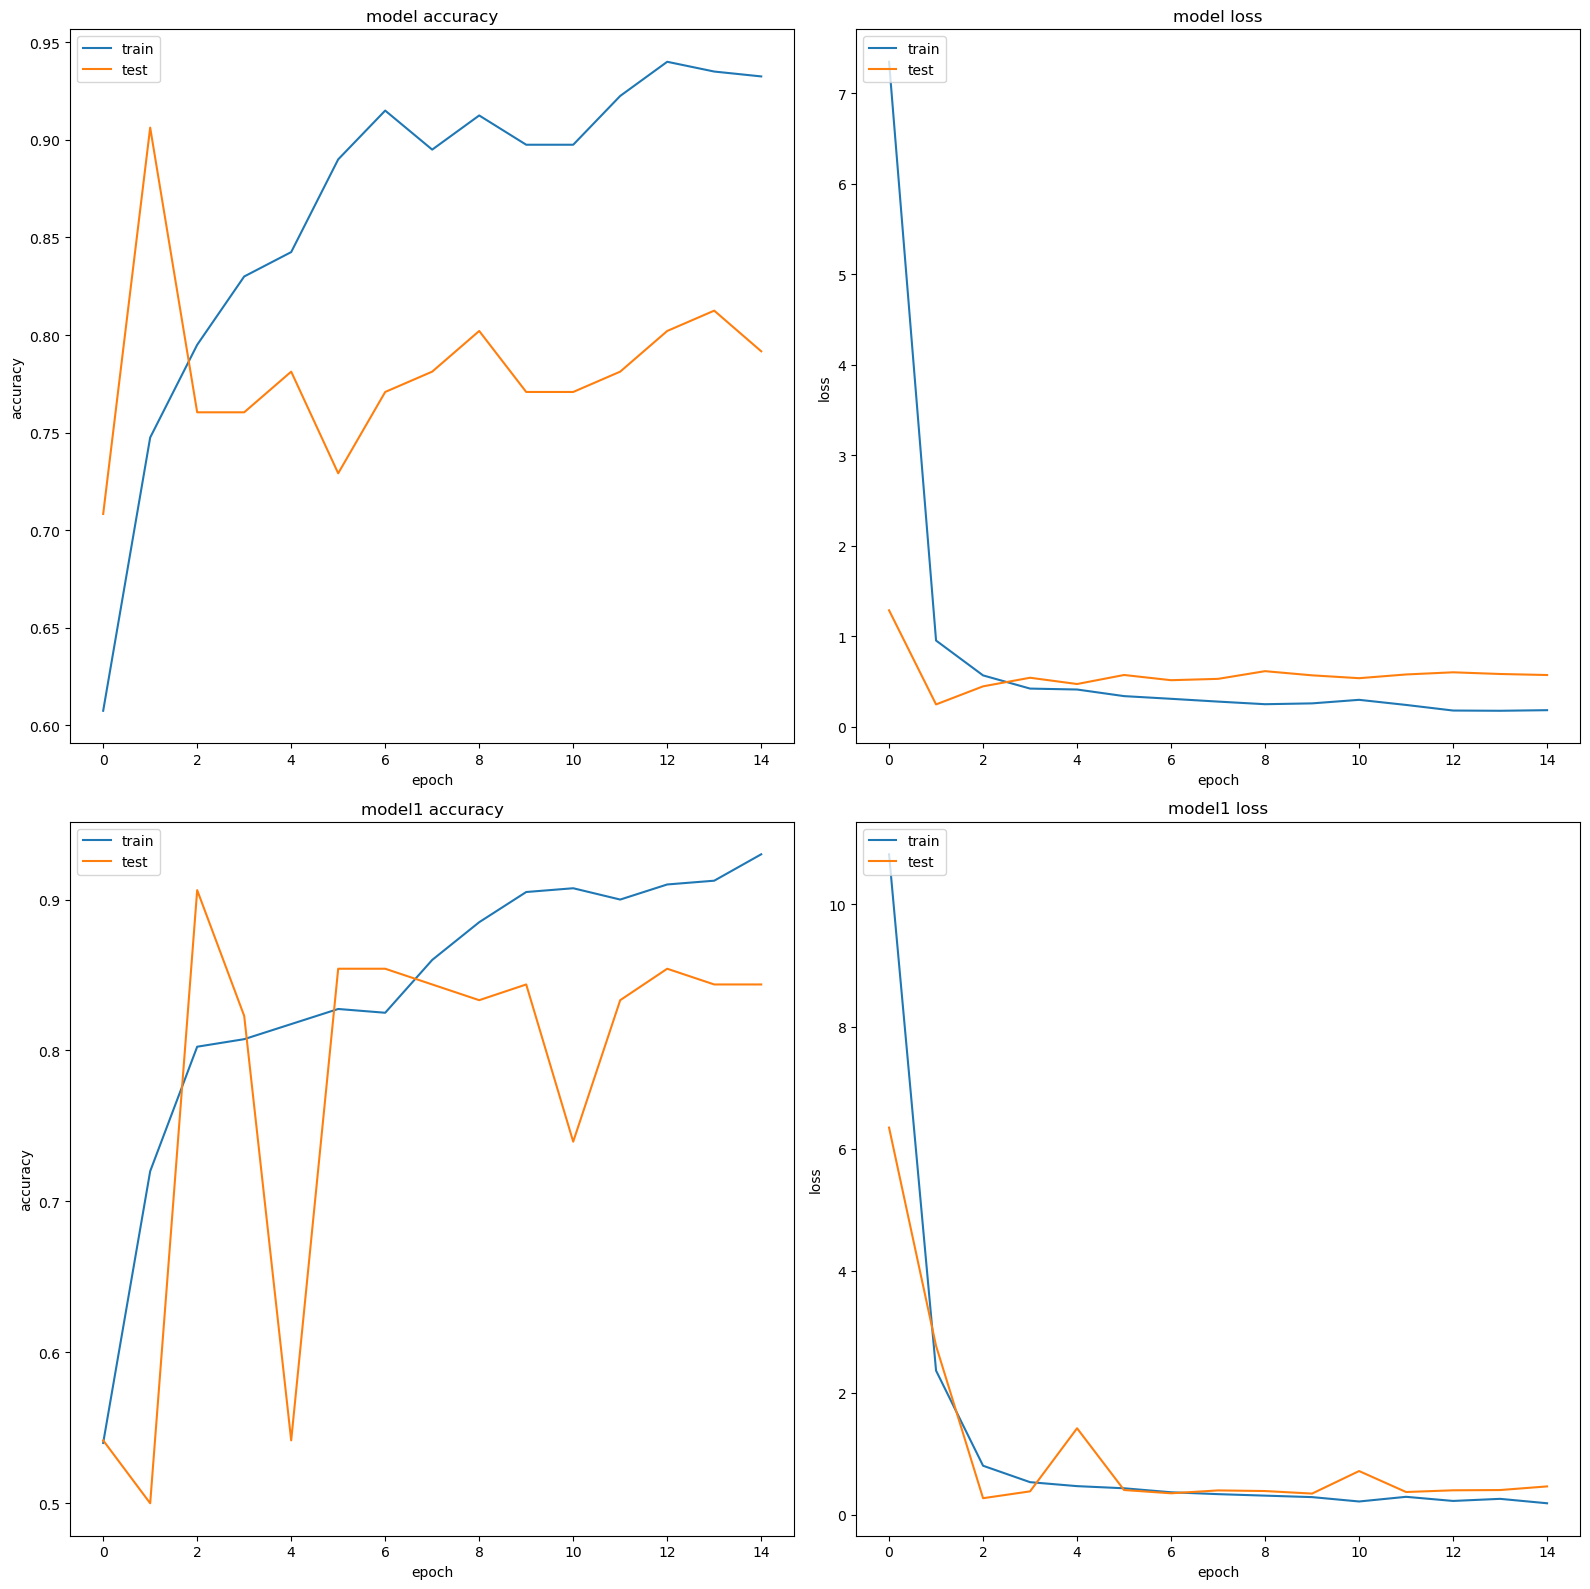

In [7]:
figure,ax=plt.subplots(2,2,figsize=(16,16))
ax[0,0].plot(history.history['accuracy'])
ax[0,0].plot(history.history['val_accuracy'])
ax[0,0].set_title('model accuracy')
ax[0,0].set_ylabel('accuracy')
ax[0,0].set_xlabel('epoch')
ax[0,0].legend(['train','test'],loc='upper left')

ax[0,1].plot(history.history['loss'])
ax[0,1].plot(history.history['val_loss'])
ax[0,1].set_title('model loss')
ax[0,1].set_ylabel('loss')
ax[0,1].set_xlabel('epoch')
ax[0,1].legend(['train','test'],loc='upper left')

ax[1,0].plot(history1.history['accuracy'])
ax[1,0].plot(history1.history['val_accuracy'])
ax[1,0].set_title('model1 accuracy')
ax[1,0].set_ylabel('accuracy')
ax[1,0].set_xlabel('epoch')
ax[1,0].legend(['train','test'],loc='upper left')

ax[1,1].plot(history1.history['loss'])
ax[1,1].plot(history1.history['val_loss'])
ax[1,1].set_title('model1 loss')
ax[1,1].set_ylabel('loss')
ax[1,1].set_xlabel('epoch')
ax[1,1].legend(['train','test'],loc='upper left')
plt.tight_layout()
plt.show()

Ici pour chaque modele on a plotte deux 4 courbes pour loss et accuracy dans les deux cas de train et de test.

Maintenant dans cette section on va changer l'architecture CNN ,on va travailler avec une autre.et on va repeter les memes etapes qu'on a fait avec les autres modeles au premier.

In [24]:
model2=keras.Sequential()
model2.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model2.add(Activation('relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Flatten())
model2.add(Dense(128))
model2.add(Dense(128))
model2.add(Dropout(0.3,seed=2))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dropout(0.3,seed=2))
model2.add(Dense(24))
model2.add(Dense(2))
model2.add(Activation('sigmoid'))
print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,731,862 (18.05 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,365,932 (9.03 MB)

None


In [25]:
model2.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

In [26]:
history2=model2.fit(train_generator1,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator1,
                    validation_steps=nb_validation_samples//batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 686ms/step - accuracy: 0.5550 - loss: 24.4812 - val_accuracy: 0.8125 - val_loss: 0.7926
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 626ms/step - accuracy: 0.6125 - loss: 3.0614 - val_accuracy: 0.7396 - val_loss: 0.5155
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 0.7525 - loss: 0.9304 - val_accuracy: 0.8646 - val_loss: 0.4028
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.7600 - loss: 0.6507 - val_accuracy: 0.8542 - val_loss: 0.4065
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 654ms/step - accuracy: 0.8100 - loss: 0.5038 - val_accuracy: 0.8229 - val_loss: 0.4182
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 0.7400 - loss: 0.5893 - val_accuracy: 0.8125 - val_loss: 0.3986
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 636ms/step - accuracy: 0.7800 - loss: 0.4635 - val_accuracy: 0.7708 - val_loss: 0.4582
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 634ms/step - accuracy: 0.8350 - loss: 0.4229 - val_acc

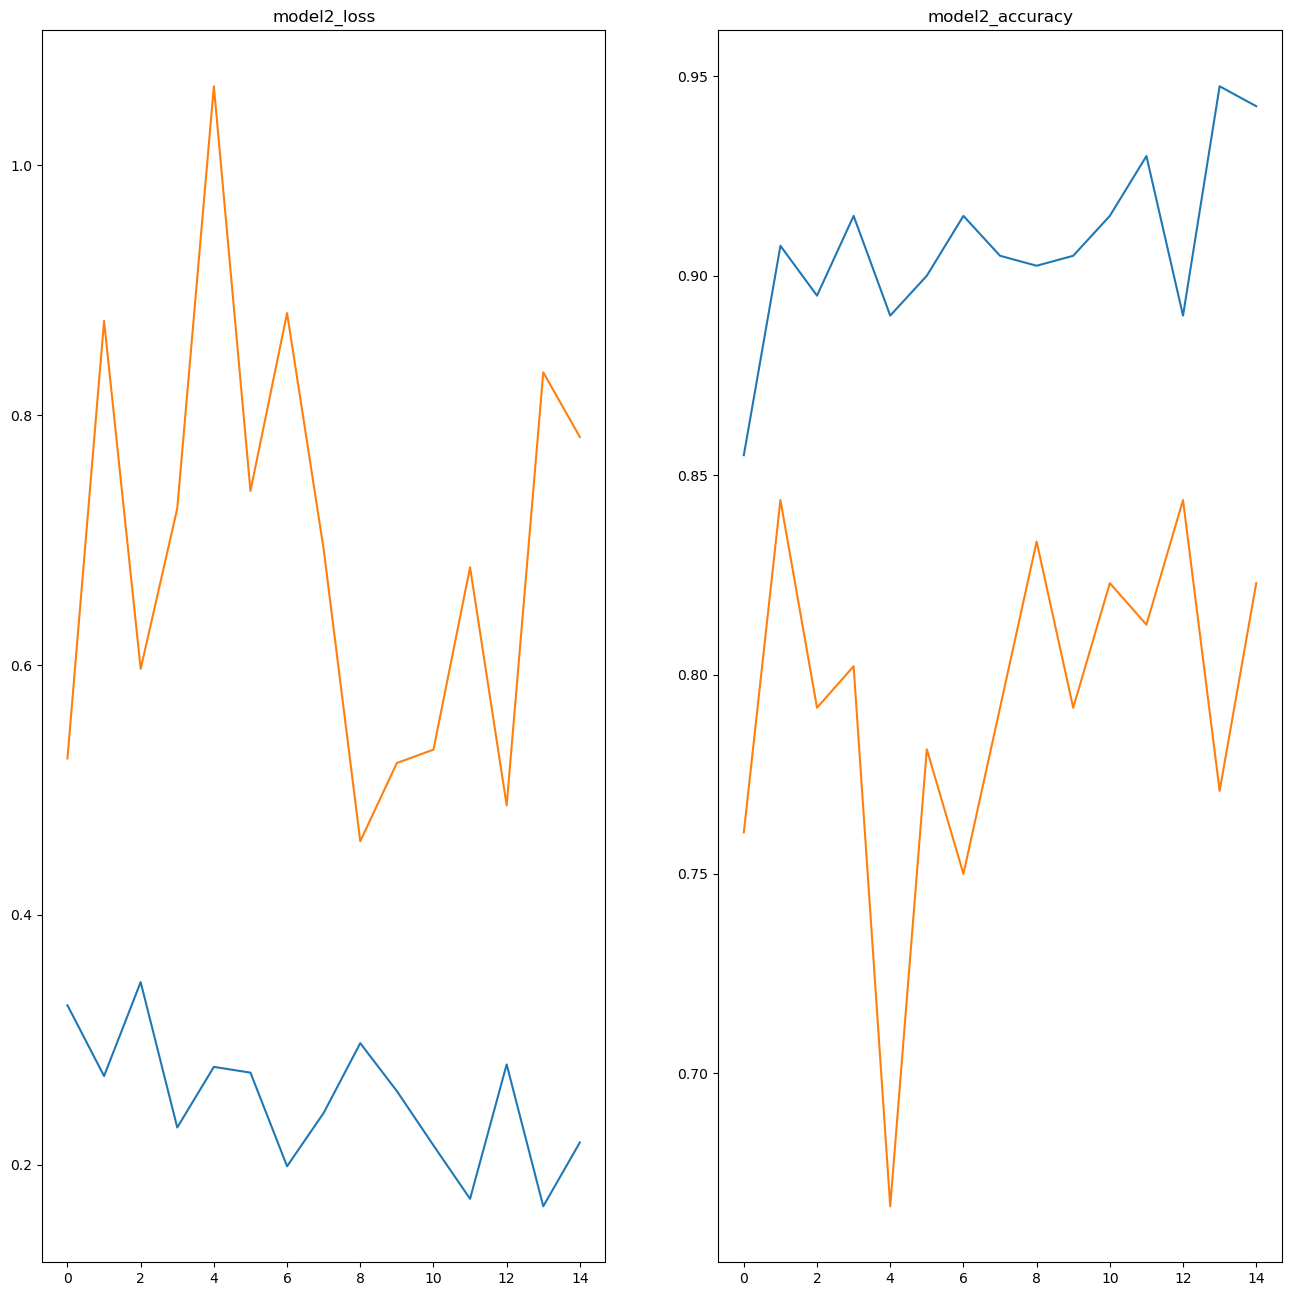

In [23]:
figure,ax=plt.subplots(1,2,figsize=(16,16))
ax[0].plot(history2.history['loss'])
ax[0].plot(history2.history['val_loss'])
ax[0].set_title("model2_loss")
ax[1].plot(history2.history['accuracy'])
ax[1].plot(history2.history['val_accuracy'])
ax[1].set_title("model2_accuracy")
plt.show()
             

###4 -Observation: 

###5